In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from ddeint import ddeint

In [2]:
# -------------------------
# Plot style helpers
# -------------------------
def setup_plot():
    plt.rcParams.update({
        "figure.figsize": (8, 4),
        "font.size": 11,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 120,
    })


def finish_plot(title=None):
    if title:
        plt.title(title, pad=12)
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


def normalize(x):
    x = np.asarray(x)
    return (x - np.min(x)) / (np.max(x) - np.min(x))

In [5]:
# -------------------------
# Hill functions
# -------------------------
def Hill_up(x, K, n):
    return x**n / (K**n + x**n)


def Hill_full(x, basal, amp, K, n):
    return basal + amp * x**n / (K**n + x**n)


def Hill_dec(x, basal, amp, K, n):
    return basal + amp * K**n / (K**n + x**n)

In [7]:
# -------------------------
# Cyclin/Cdk parameters
# -------------------------
ks_cyc = 1.5

deg_a, deg_b, deg_K, deg_n = 0.01, 0.06, 32.0, 17.0
cdc25_a, cdc25_b, cdc25_K, cdc25_n = 0.8, 4.0, 35.0, 11.0
wee1_a, wee1_b, wee1_K, wee1_n = 0.4, 2.0, 30.0, 3.5

In [9]:
# -------------------------
# PLK4-reset oscillator parameters
# -------------------------
ks_plk = 1.1
kd_plk = 1.0

Kp = 0.9
nP = 8.0

tau = 18.0

R_tot = 1.0
k_inactivate = 1.3
k_reset_base = 0.03
k_reset_cdk = 0.25

Ka = 30.0
m = 3.0

In [11]:
def run_simulation(epsilon=0.0, T=600, dt=0.05):

    # -------------------------
    # DDE system
    # -------------------------
    def model(Y, t):
    
        c, a, P, R = Y(t)
        c_tau, a_tau, P_tau, R_tau = Y(t - tau)
    
        # Cyclin/Cdk oscillator
        dc_dt = ks_cyc - Hill_full(a, deg_a, deg_b, deg_K, deg_n) * c
    
        da_dt = (
            Hill_full(a, cdc25_a, cdc25_b, cdc25_K, cdc25_n) * (c - a)
            - Hill_dec(a, wee1_a, wee1_b, wee1_K, wee1_n) * a
            + ks_cyc
            - Hill_full(a, deg_a, deg_b, deg_K, deg_n) * a
        )
    
        #Coupling
        phi_a = Hill_up(a, Ka, m)
        delayed_inhibition = Hill_up(P_tau, Kp, nP)
    
        reset_rate = k_reset_base + k_reset_cdk * phi_a * epsilon
    
        dR_dt = (
            reset_rate * (R_tot - R)
            - k_inactivate * delayed_inhibition * R
        )
    
        dP_dt = ks_plk - kd_plk * P - kd_plk * P * delayed_inhibition * (1 - epsilon * phi_a)
        
        return np.array([dc_dt, da_dt, dP_dt, dR_dt])

    
    # ----------------
    # History function 
    # ----------------
    def history(t):
        return np.array([55.0, 25.0, 0.8, 0.8])

    
    #Time vector
    tt = np.arange(0, T, dt)

    #Solve
    yy = ddeint(model, history, tt)

    c_vals = yy[:, 0]
    a_vals = yy[:, 1]
    P_vals = yy[:, 2]
    R_vals = yy[:, 3]

    Phi_vals = a_vals**m / (Ka**m + a_vals**m)

    return tt, c_vals, a_vals, P_vals, R_vals, Phi_vals

In [44]:
from scipy.signal import hilbert, find_peaks
import numpy as np

eps_values = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50, 0.75, 1]

freq_cdk = []
freq_plk4 = []
freq_common = []
plv_values = []

start_time = 200

for eps in eps_values:

    times, c_coup, cdk, plk4, _, Phi = run_simulation(epsilon=eps)

    mask = times >= start_time
    t = times[mask]

    cdk = cdk[mask]
    plk4 = plk4[mask]

    # -------------------------
    # 1. Frequency (CDK)
    # -------------------------
    peaks_cdk = find_peaks(cdk, prominence=2, distance=20)[0]
    t_peaks_cdk = t[peaks_cdk]

    if len(t_peaks_cdk) > 1:
        freq_cdk_val = 1 / np.mean(np.diff(t_peaks_cdk))
    else:
        freq_cdk_val = np.nan

    # -------------------------
    # 2. Frequency (PLK4)
    # -------------------------
    peaks_plk4 = find_peaks(plk4, prominence=2, distance=20)[0]
    t_peaks_plk4 = t[peaks_plk4]

    if len(t_peaks_plk4) > 1:
        freq_plk4_val = 1 / np.mean(np.diff(t_peaks_plk4))
    else:
        freq_plk4_val = np.nan

    freq_cdk.append(freq_cdk_val)
    freq_plk4.append(freq_plk4_val)

    # -------------------------
    # 3. Phase locking (Hilbert)
    # -------------------------
    phi_cdk = np.angle(hilbert(cdk))
    phi_plk4 = np.angle(hilbert(plk4))

    phase_diff = phi_cdk - phi_plk4

    plv = np.abs(np.mean(np.exp(1j * phase_diff)))
    plv_values.append(plv)

In [46]:
print(phase_diff)
print(plv_values)

[-0.23157997 -0.12597472 -0.12482407 ... -0.22800835 -0.22653963
 -0.39099832]
[0.8572952459515449, 0.8623846917698035, 0.8666763115068993, 0.8736271111000545, 0.8833699091177518, 0.8952529247104317, 0.9240838172300239, 0.9423748523121463]


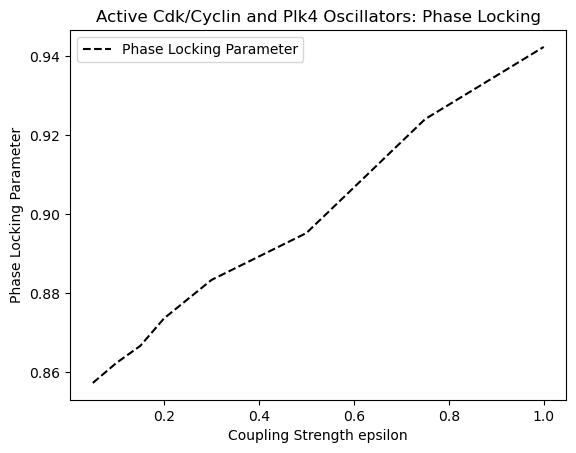

In [48]:
fig, ax1 = plt.subplots()

ax1.plot(eps_values, plv_values, 'k--', label="Phase Locking Parameter")
ax1.set_ylabel("Phase Locking Parameter")
ax1.set_xlabel('Coupling Strength epsilon')

plt.legend()
plt.title("Active Cdk/Cyclin and Plk4 Oscillators: Phase Locking")
plt.savefig("PhaseLocking.png")
plt.show()

In [ ]:
#take epsilon = 0.5
#vary one of the parameters (k_d) for large variation and small variation around what was used before
#calculate phase locking parameter in function of k_d

In [21]:
#kd around 1
from scipy.signal import hilbert, find_peaks
epsilon_pars = 0.10
k_d_vals = [0.80, 0.85, 0.90, 0.95, 1.0, 1.05, 1.1, 1.15, 1.20]

freq_cdk = []
freq_plk4 = []
freq_common = []
plv_values1 = []

start_time = 200

for kd in k_d_vals:
    kd_plk = kd
    times, c_coup, cdk, plk4, _, Phi = run_simulation(epsilon=epsilon_pars)

    mask = times >= start_time
    t = times[mask]

    cdk = cdk[mask]
    plk4 = plk4[mask]

    # -------------------------
    # 1. Frequency (CDK)
    # -------------------------
    peaks_cdk = find_peaks(cdk, prominence=2, distance=20)[0]
    t_peaks_cdk = t[peaks_cdk]

    if len(t_peaks_cdk) > 1:
        freq_cdk_val = 1 / np.mean(np.diff(t_peaks_cdk))
    else:
        freq_cdk_val = np.nan

    # -------------------------
    # 2. Frequency (PLK4)
    # -------------------------
    peaks_plk4 = find_peaks(plk4, prominence=2, distance=20)[0]
    t_peaks_plk4 = t[peaks_plk4]

    if len(t_peaks_plk4) > 1:
        freq_plk4_val = 1 / np.mean(np.diff(t_peaks_plk4))
    else:
        freq_plk4_val = np.nan

    freq_cdk.append(freq_cdk_val)
    freq_plk4.append(freq_plk4_val)

    # -------------------------
    # 3. Phase locking (Hilbert)
    # -------------------------
    phi_cdk = np.angle(hilbert(cdk))
    phi_plk4 = np.angle(hilbert(plk4))

    phase_diff = phi_cdk - phi_plk4

    plv1 = np.abs(np.mean(np.exp(1j * phase_diff)))
    plv_values1.append(plv1)

In [23]:
print(plv_values1)

[0.8623846917698035, 0.8554368508323577, 0.8524946851687359, 0.8520474205883454, 0.8544815139905775, 0.8650945950463867, 0.8822272248333266, 0.8856206972672865, 0.887850654569118]


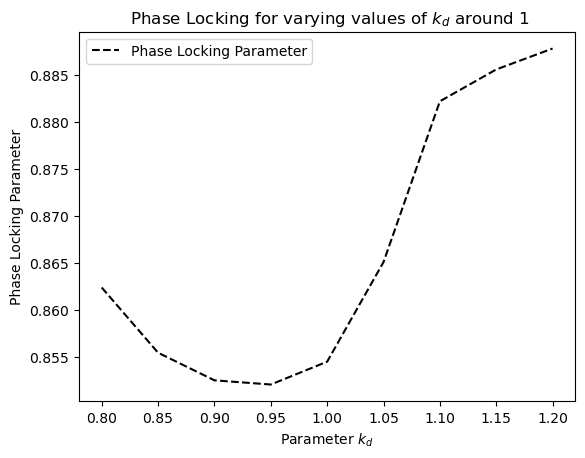

In [25]:
fig, ax1 = plt.subplots()

ax1.plot(k_d_vals, plv_values1, 'k--', label="Phase Locking Parameter")
ax1.set_ylabel("Phase Locking Parameter")
ax1.set_xlabel(r'Parameter $k_d$')

plt.legend()
plt.title(r" Phase Locking for varying values of $k_d$ around 1")
plt.savefig("kd_close_to_1.png")
plt.show()

In [27]:
#kd far from 1
epsilon_pars = 0.10
k_d_vals = [0.10, 0.20, 0.40, 0.80, 1.0, 1.20, 1.60, 1.80, 1.90]

freq_cdk = []
freq_plk4 = []
freq_common = []
plv_values2 = []

start_time = 200

for kd in k_d_vals:
    kd_plk = kd
    times, c_coup, cdk, plk4, _, Phi = run_simulation(epsilon=epsilon_pars)

    mask = times >= start_time
    t = times[mask]

    cdk = cdk[mask]
    plk4 = plk4[mask]

    # -------------------------
    # 1. Frequency (CDK)
    # -------------------------
    peaks_cdk = find_peaks(cdk, prominence=2, distance=20)[0]
    t_peaks_cdk = t[peaks_cdk]

    if len(t_peaks_cdk) > 1:
        freq_cdk_val = 1 / np.mean(np.diff(t_peaks_cdk))
    else:
        freq_cdk_val = np.nan

    # -------------------------
    # 2. Frequency (PLK4)
    # -------------------------
    peaks_plk4 = find_peaks(plk4, prominence=2, distance=20)[0]
    t_peaks_plk4 = t[peaks_plk4]

    if len(t_peaks_plk4) > 1:
        freq_plk4_val = 1 / np.mean(np.diff(t_peaks_plk4))
    else:
        freq_plk4_val = np.nan

    freq_cdk.append(freq_cdk_val)
    freq_plk4.append(freq_plk4_val)

    # -------------------------
    # 3. Phase locking (Hilbert)
    # -------------------------
    phi_cdk = np.angle(hilbert(cdk))
    phi_plk4 = np.angle(hilbert(plk4))

    phase_diff = phi_cdk - phi_plk4

    plv2 = np.abs(np.mean(np.exp(1j * phase_diff)))
    plv_values2.append(plv2)

[0.9423748523121463, 0.9423748523121463, 0.9423748523121463, 0.9423748523121463, 0.9423748523121463, 0.9423748523121463, 0.9423748523121463, 0.9423748523121463, 0.9423748523121463]


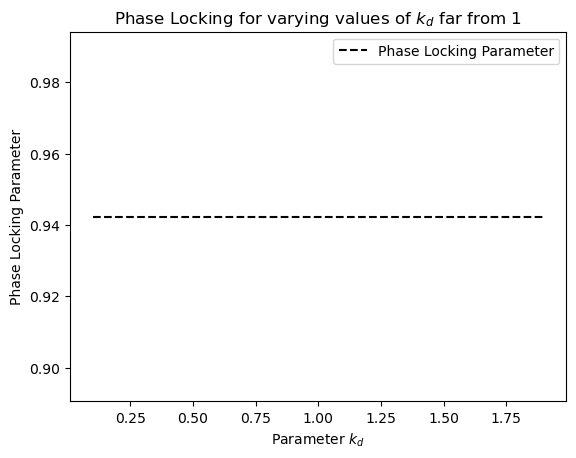

In [88]:
fig, ax1 = plt.subplots()
print(plv_values2)

ax1.plot(k_d_vals, plv_values2, 'k--', label="Phase Locking Parameter")
ax1.set_ylabel("Phase Locking Parameter")
ax1.set_xlabel(r'Parameter $k_d$')

plt.legend()
plt.title(r"Phase Locking for varying values of $k_d$ far from 1")
plt.savefig("kd_far_from_1.png")
plt.show()